# **4. Splines de regresión con funciones base.**

Temas selectos de aprendizaje de máquina \
Ana Luisa Llamas Martinez

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from ISLP import load_data

from ISLP.models import (
    ModelSpec as MS,
    summarize,
    bs,
    ns,
    poly
)

from ISLP.transforms import (
    BSpline,
    NaturalSpline
)

## 4.3 Cargar los datos Wage.

In [3]:
Wage = load_data('Wage')
Wage.shape

(3000, 11)

In [4]:
age = Wage['age']
wage = Wage['wage']

## 4.6 Construir directamente una base B-spline.

In [5]:
bs_transform = BSpline(internal_knots=[25, 40, 60], intercept = True)
bs_transform

,intercept,True
,internal_knots,"[25, 40, ...]"
,degree,3
,lower_bound,None
,upper_bound,None
,df,None
,ext,0


In [6]:
bs_transform = bs_transform.fit(age)

In [7]:
bs_age = bs_transform.transform(age)
bs_age

,"BSpline(intercept=True, internal_knots=[25, 40, 60],\n lower_bound=np.float64(18.0), upper_bound=np.float64(80.0))[0]","BSpline(intercept=True, internal_knots=[25, 40, 60],\n lower_bound=np.float64(18.0), upper_bound=np.float64(80.0))[1]","BSpline(intercept=True, internal_knots=[25, 40, 60],\n lower_bound=np.float64(18.0), upper_bound=np.float64(80.0))[2]","BSpline(intercept=True, internal_knots=[25, 40, 60],\n lower_bound=np.float64(18.0), upper_bound=np.float64(80.0))[3]","BSpline(intercept=True, internal_knots=[25, 40, 60],\n lower_bound=np.float64(18.0), upper_bound=np.float64(80.0))[4]","BSpline(intercept=True, internal_knots=[25, 40, 60],\n lower_bound=np.float64(18.0), upper_bound=np.float64(80.0))[5]","BSpline(intercept=True, internal_knots=[25, 40, 60],\n lower_bound=np.float64(18.0), upper_bound=np.float64(80.0))[6]"
0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1,0.002915,0.559911,0.403778,0.033395,0.000000,0.000000,0.0
2,0.000000,0.000000,0.114796,0.618564,0.262733,0.003906,0.0
3,0.000000,0.000000,0.167109,0.633167,0.198880,0.000844,0.0
4,0.000000,0.000000,0.034014,0.508194,0.426542,0.031250,0.0
...,...,...,...,...,...,...,...
2995,0.000000,0.000000,0.139320,0.628472,0.230208,0.002000,0.0
2996,0.000000,0.137741,0.629111,0.228819,0.004329,0.000000,0.0
2997,0.000000,0.302617,0.586851,0.110255,0.000277,0.000000,0.0
2998,0.000000,0.302617,0.586851,0.110255,0.000277,0.000000,0.0


## 4.7 ¿Qué representan las columnas de la base?

In [8]:
age_order = np.argsort(age.to_numpy())
age_sorter = age.to_numpy()[age_order]

In [9]:
bs_sorted = bs_age.iloc[age_order, :].to_numpy()


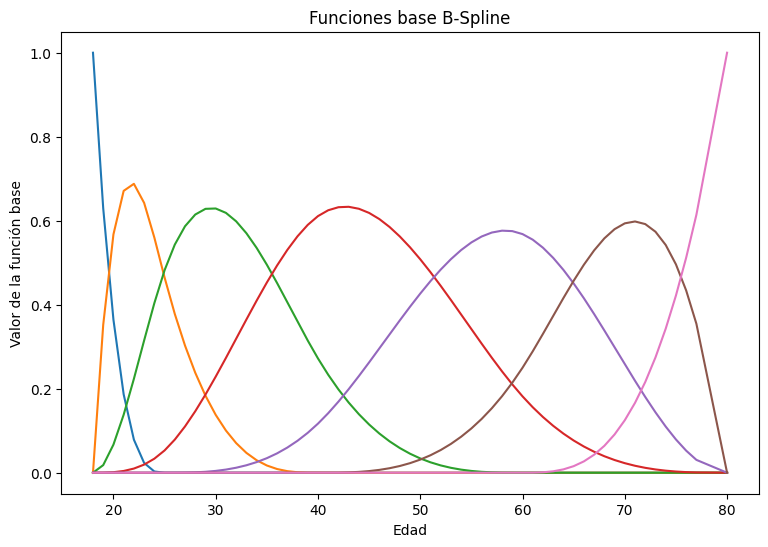

In [10]:
plt.figure(figsize= (9,6))

for j in range(bs_sorted.shape[1]):
    plt.plot(age_sorter, bs_sorted[:,j], label = f'Base {j+1}')

plt.xlabel("Edad")
plt.ylabel("Valor de la función base")
plt.title("Funciones base B-Spline")
plt.show()

## 4.9 ¿Por qué aparecen menos coeficientes de spline?

In [11]:
bs_age_spec = MS([bs('age', internal_knots=[25,40,60], name='bs(age)')])

In [12]:
bs_age_spec = bs_age_spec.fit(Wage)

In [13]:
X_bs = bs_age_spec.transform(Wage)
X_bs.head()

,intercept,bs(age)[0],bs(age)[1],bs(age)[2],bs(age)[3],bs(age)[4],bs(age)[5]
0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1,1.0,0.559911,0.403778,0.033395,0.000000,0.000000,0.0
2,1.0,0.000000,0.114796,0.618564,0.262733,0.003906,0.0
3,1.0,0.000000,0.167109,0.633167,0.198880,0.000844,0.0
4,1.0,0.000000,0.034014,0.508194,0.426542,0.031250,0.0


In [14]:
model_bs = sm.OLS(wage, X_bs).fit()

In [15]:
summarize(model_bs)

,coef,std err,t,P>|t|
intercept,60.4937,9.460,6.394,0.000
bs(age)[0],3.9805,12.538,0.317,0.751
bs(age)[1],44.6310,9.626,4.636,0.000
bs(age)[2],62.8388,10.755,5.843,0.000
bs(age)[3],55.9908,10.706,5.230,0.000
bs(age)[4],50.6881,14.402,3.520,0.000
bs(age)[5],16.6061,19.126,0.868,0.385


## 4.10 Predicciones sobre una malla de edades.

In [16]:
age_grid = np.linspace(
    age.min(),
    age.max(),
    500
)

age_grid_df = pd.DataFrame({
    "age": age_grid
})

In [17]:
X_grid_bs = bs_age_spec.transform(age_grid_df)
pred_bs = model_bs.get_prediction(X_grid_bs)

In [18]:

pred_bs_summary = pred_bs.summary_frame()

pred_bs_summary.head()

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,60.493714,9.460394,41.944181,79.043247,-19.956535,140.943964
1,60.714068,8.872971,43.316329,78.111808,-19.478442,140.906579
2,60.950942,8.317109,44.643114,77.258770,-19.012192,140.914075
3,61.203929,7.792733,45.924273,76.483584,-18.555869,140.963726
4,61.472623,7.299800,47.159489,75.785757,-18.107672,141.052917


## 4.11 Graficar el spline cúbico.

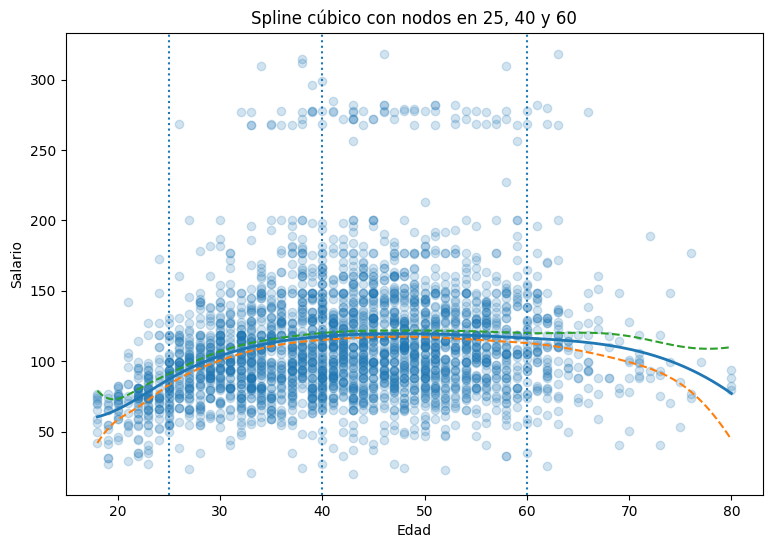

In [19]:
plt.figure(figsize=(9, 6))

plt.scatter(
    age,
    wage,
    alpha=0.20
)

plt.plot(
    age_grid,
    pred_bs_summary["mean"],
    linewidth=2
)

plt.plot(
    age_grid,
    pred_bs_summary["mean_ci_lower"],
    linestyle="--"
)

plt.plot(
    age_grid,
    pred_bs_summary["mean_ci_upper"],
    linestyle="--"
)

plt.axvline(25, linestyle=":")
plt.axvline(40, linestyle=":")
plt.axvline(60, linestyle=":")

plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title("Spline cúbico con nodos en 25, 40 y 60")

plt.show()

## 4.12 Inspeccionar los nodos.

In [20]:
bs_check = BSpline(
    internal_knots=[25, 40, 60]
).fit(age)

bs_check.internal_knots_

array([25, 40, 60])

## 4.13 Elegir la complejidad mediante grados de libertad.

In [21]:
bs_df6 = BSpline(
    df=6
).fit(age)

In [22]:
bs_df6.internal_knots_

array([33.75, 42.  , 51.  ])

In [23]:
age.quantile([0.25, 0.50, 0.75])

0.25    33.75
0.50    42.00
0.75    51.00
Name: age, dtype: float64

## 4.14 Ajustar un spline usando grados de libertad

In [24]:
bs_df_spec = MS([
    bs(
        "age",
        df=6
    )
]).fit(Wage)

In [25]:
X_bs_df = bs_df_spec.transform(Wage)

model_bs_df = sm.OLS(
    wage,
    X_bs_df
).fit()

summarize(model_bs_df)

,coef,std err,t,P>|t|
intercept,56.3138,7.258,7.759,0.000
"bs(age, df=6)[0]",27.8240,12.435,2.238,0.025
"bs(age, df=6)[1]",54.0625,7.127,7.585,0.000
"bs(age, df=6)[2]",65.8284,8.323,7.909,0.000
"bs(age, df=6)[3]",55.8127,8.724,6.398,0.000
"bs(age, df=6)[4]",72.1315,13.745,5.248,0.000
"bs(age, df=6)[5]",14.7509,16.209,0.910,0.363


## 4.15 Visualizar el spline con df=6.

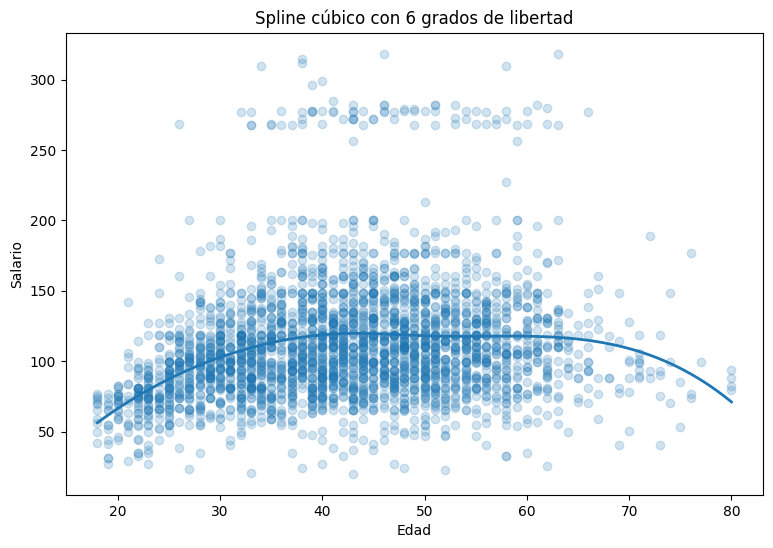

In [26]:
X_grid_bs_df = bs_df_spec.transform(age_grid_df)

pred_bs_df = model_bs_df.get_prediction(
    X_grid_bs_df
).summary_frame()

plt.figure(figsize=(9, 6))

plt.scatter(
    age,
    wage,
    alpha=0.20
)

plt.plot(
    age_grid,
    pred_bs_df["mean"],
    linewidth=2
)

plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title("Spline cúbico con 6 grados de libertad")

plt.show()

## 4.16 Splines de grado cero.

In [27]:
degree=0

bs_degree0_spec = MS([
    bs(
        "age",
        df=3,
        degree=0
    )
]).fit(Wage)

X_degree0 = bs_degree0_spec.transform(Wage)

model_degree0 = sm.OLS(
    wage,
    X_degree0
).fit()

summarize(model_degree0)


,coef,std err,t,P>|t|
intercept,94.1584,1.478,63.687,0.0
"bs(age, df=3, degree=0)[0]",22.3490,2.152,10.388,0.0
"bs(age, df=3, degree=0)[1]",24.8076,2.044,12.137,0.0
"bs(age, df=3, degree=0)[2]",22.7814,2.087,10.917,0.0


## 4.17 Visualizar el spline de grado cero.

In [28]:
X_grid_degree0 = bs_degree0_spec.transform(
    age_grid_df
)

pred_degree0 = model_degree0.predict(
    X_grid_degree0
)

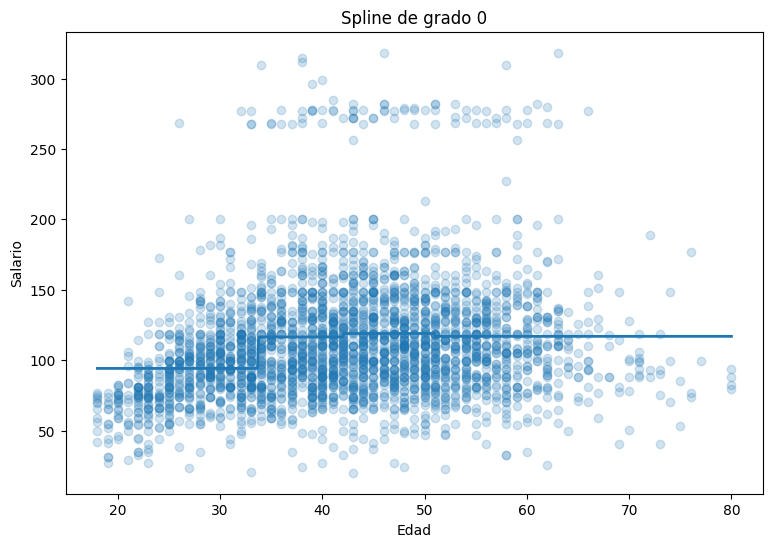

In [29]:
plt.figure(figsize=(9, 6))

plt.scatter(
    age,
    wage,
    alpha=0.20
)

plt.plot(
    age_grid,
    pred_degree0,
    linewidth=2
)

plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title("Spline de grado 0")

plt.show()

## 4.18 Conexión con qcut().

In [30]:
age_bins = pd.qcut(
    age,
    q=4
)

age_bins.value_counts().sort_index()

age
(17.999, 33.75]    750
(33.75, 42.0]      759
(42.0, 51.0]       817
(51.0, 80.0]       674
Name: count, dtype: int64

## 4.20 Ajustar un spline natural.

In [31]:
ns_age_spec = MS([
    ns(
        "age",
        df=5
    )
]).fit(Wage)

In [32]:
X_ns = ns_age_spec.transform(Wage)

X_ns.head()

,intercept,"ns(age, df=5)[0]","ns(age, df=5)[1]","ns(age, df=5)[2]","ns(age, df=5)[3]","ns(age, df=5)[4]"
0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
1,1.0,0.026239,0.000000,-0.156378,0.353299,-0.196921
2,1.0,0.246963,0.698914,0.046645,0.016069,-0.008957
3,1.0,0.436710,0.537522,0.010563,0.012123,-0.006757
4,1.0,0.013120,0.694036,0.250206,0.086371,-0.043733


In [33]:
model_ns = sm.OLS(
    wage,
    X_ns
).fit()

summarize(model_ns)

,coef,std err,t,P>|t|
intercept,60.4752,4.708,12.844,0.000
"ns(age, df=5)[0]",61.5267,4.709,13.065,0.000
"ns(age, df=5)[1]",55.6912,5.717,9.741,0.000
"ns(age, df=5)[2]",46.8184,4.948,9.463,0.000
"ns(age, df=5)[3]",83.2036,11.918,6.982,0.000
"ns(age, df=5)[4]",6.8770,9.484,0.725,0.468


## 4.21 Graficar el spline natural.

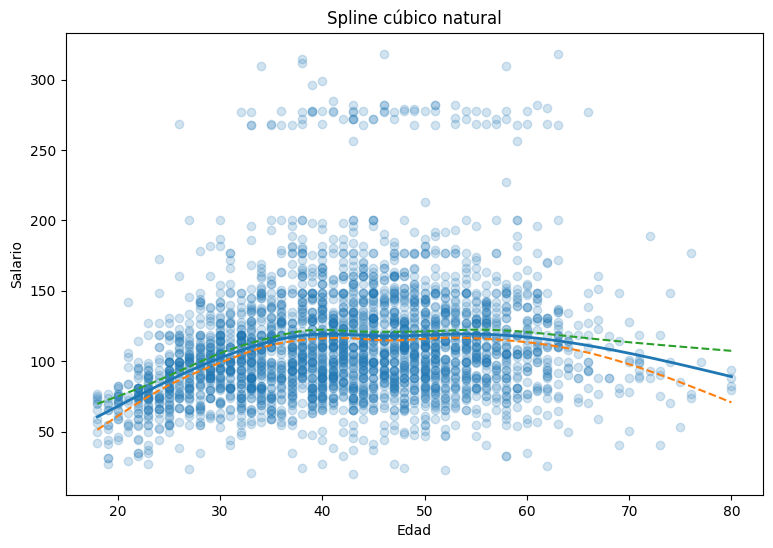

In [34]:
X_grid_ns = ns_age_spec.transform(
    age_grid_df
)

pred_ns = model_ns.get_prediction(
    X_grid_ns
).summary_frame()

plt.figure(figsize=(9, 6))

plt.scatter(
    age,
    wage,
    alpha=0.20
)

plt.plot(
    age_grid,
    pred_ns["mean"],
    linewidth=2
)

plt.plot(
    age_grid,
    pred_ns["mean_ci_lower"],
    linestyle="--"
)

plt.plot(
    age_grid,
    pred_ns["mean_ci_upper"],
    linestyle="--"
)

plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title("Spline cúbico natural")

plt.show()


## 4.22 Comparar spline cúbico y spline natural.

In [35]:
cubic_spec = MS([
    bs(
        "age",
        df=5
    )
]).fit(Wage)

natural_spec = MS([
    ns(
        "age",
        df=5
    )
]).fit(Wage)

In [36]:
model_cubic = sm.OLS(
    wage,
    cubic_spec.transform(Wage)
).fit()

model_natural = sm.OLS(
    wage,
    natural_spec.transform(Wage)
).fit()

In [37]:
pred_cubic = model_cubic.predict(
    cubic_spec.transform(age_grid_df)
)

pred_natural = model_natural.predict(
    natural_spec.transform(age_grid_df)
)

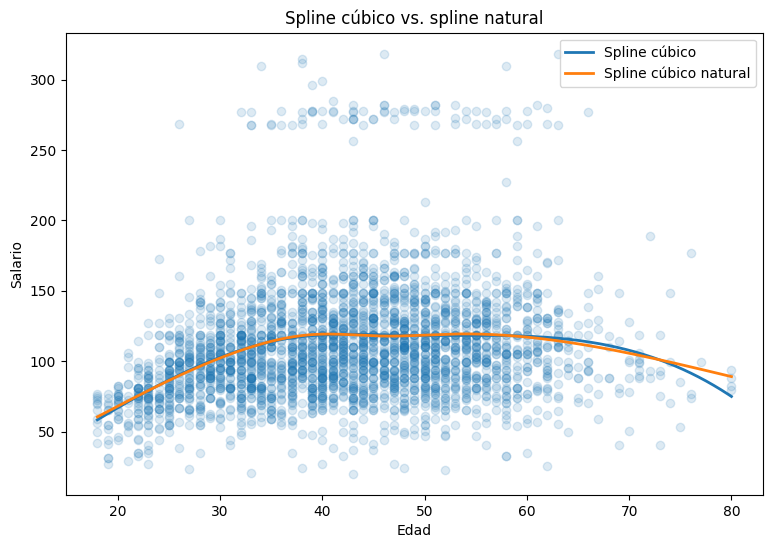

In [38]:
plt.figure(figsize=(9, 6))

plt.scatter(
    age,
    wage,
    alpha=0.15
)

plt.plot(
    age_grid,
    pred_cubic,
    linewidth=2,
    label="Spline cúbico"
)

plt.plot(
    age_grid,
    pred_natural,
    linewidth=2,
    label="Spline cúbico natural"
)

plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title("Spline cúbico vs. spline natural")
plt.legend()

plt.show()

## 4.23 Comparación con regresión polinómica.

In [39]:
poly15_spec = MS([
    poly(
        "age",
        degree=15
    )
]).fit(Wage)

model_poly15 = sm.OLS(
    wage,
    poly15_spec.transform(Wage)
).fit()

In [40]:
ns15_spec = MS([
    ns(
        "age",
        df=15
    )
]).fit(Wage)

model_ns15 = sm.OLS(
    wage,
    ns15_spec.transform(Wage)
).fit()

In [41]:
pred_poly15 = model_poly15.predict(
    poly15_spec.transform(age_grid_df)
)

pred_ns15 = model_ns15.predict(
    ns15_spec.transform(age_grid_df)
)

## 4.24 Visualizar la comparación.

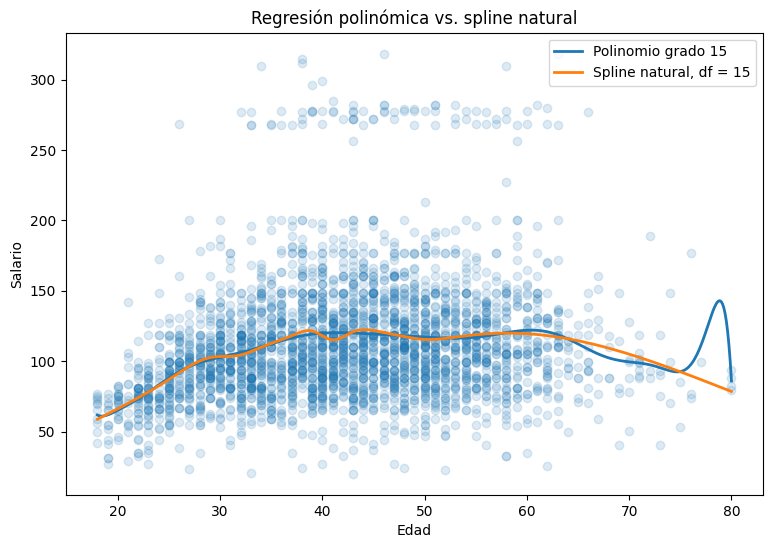

In [42]:
plt.figure(figsize=(9, 6))

plt.scatter(
    age,
    wage,
    alpha=0.15
)

plt.plot(
    age_grid,
    pred_poly15,
    linewidth=2,
    label="Polinomio grado 15"
)

plt.plot(
    age_grid,
    pred_ns15,
    linewidth=2,
    label="Spline natural, df = 15"
)

plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title("Regresión polinómica vs. spline natural")
plt.legend()

plt.show()

## 4.25 Error de entrenamiento y complejidad.

In [43]:
dfs = range(3, 16)

results = []

for df in dfs:

    spec = MS([
        bs(
            "age",
            df=df
        )
    ]).fit(Wage)

    X = spec.transform(Wage)

    model = sm.OLS(
        wage,
        X
    ).fit()

    predictions = model.predict(X)

    mse = np.mean(
        (wage - predictions) ** 2
    )

    results.append({
        "df": df,
        "MSE_train": mse
    })

In [44]:
results_df = pd.DataFrame(results)

results_df

,df,MSE_train
0,3,1592.558134
1,4,1591.033237
2,5,1588.790102
3,6,1588.748156
4,7,1588.457260
5,8,1587.854910
6,9,1586.834849
7,10,1584.669925
8,11,1584.083216
9,12,1584.371360


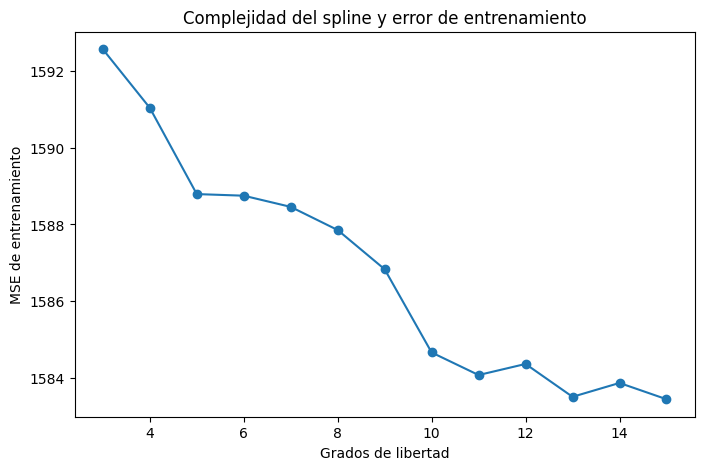

In [45]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["df"],
    results_df["MSE_train"],
    marker="o"
)

plt.xlabel("Grados de libertad")
plt.ylabel("MSE de entrenamiento")
plt.title("Complejidad del spline y error de entrenamiento")

plt.show()

# EJERCICIOS 

**4.27.1 Ejercicio 1.** Construye un spline cúbico para age utilizando nodos interiores en 30, 45 y 55.


Realiza lo siguiente:
1) ajusta el modelo;

In [46]:
bs_age_spec1 = MS([
    bs(
        "age",
        internal_knots=[30, 45, 55]
    )
])

bs_age_spec1 = bs_age_spec1.fit(Wage)
X_bs1 = bs_age_spec1.transform(Wage)

model_bs1 = sm.OLS(
    wage,
    X_bs1
).fit()

2) obtén sus predicciones sobre age_grid;

In [47]:
age_grid1 = np.linspace(
    age.min(),
    age.max(),
    500
)

age_grid_df1 = pd.DataFrame({
    "age": age_grid1
})

X_grid_bs1 = bs_age_spec1.transform(age_grid_df1)

pred_bs1 = model_bs1.get_prediction(X_grid_bs1)

pred_bs_summary1 = pred_bs1.summary_frame()

pred_bs_summary1.head()

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,57.803560,7.838813,42.433553,73.173567,-21.954081,137.561202
1,58.338329,7.515568,43.602126,73.074532,-21.299601,137.976259
2,58.873345,7.203135,44.749748,72.996943,-20.653507,138.400198
3,59.408560,6.901483,45.876430,72.940690,-20.015384,138.832503
4,59.943922,6.610584,46.982174,72.905670,-19.384831,139.272676


3) grafica los datos y la curva ajustada;
4) marca los nodos con líneas verticales;

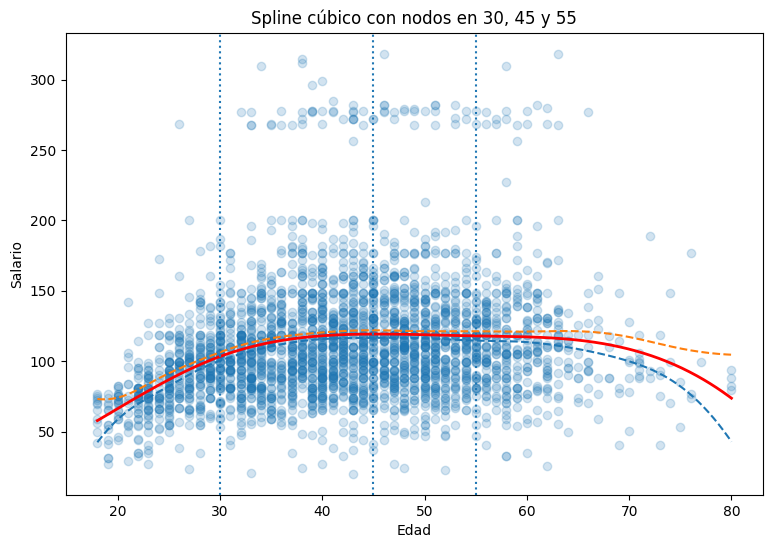

In [48]:
plt.figure(figsize=(9, 6))

plt.scatter(
    age,
    wage,
    alpha=0.20
)

plt.plot(
    age_grid1,
    pred_bs_summary1["mean"],
    linewidth=2,
    color = "red"
)

plt.plot(
    age_grid1,
    pred_bs_summary1["mean_ci_lower"],
    linestyle="--"
)

plt.plot(
    age_grid1,
    pred_bs_summary1["mean_ci_upper"],
    linestyle="--"
)

plt.axvline(30, linestyle=":")
plt.axvline(45, linestyle=":")
plt.axvline(55, linestyle=":")

plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title("Spline cúbico con nodos en 30, 45 y 55")

plt.show()

5) compara visualmente el resultado con el spline que utilizó nodos en 25, 40 y 60.

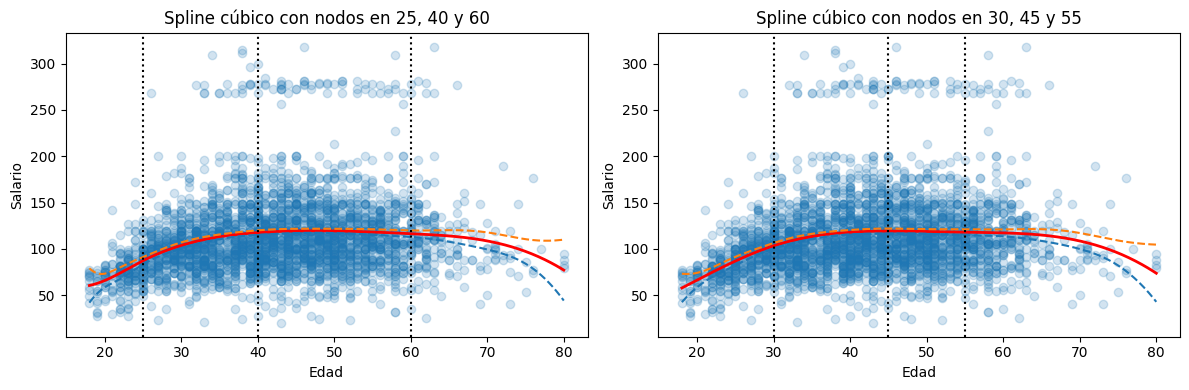

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(age, wage, alpha=0.20)
axes[0].plot(age_grid, pred_bs_summary["mean"], linewidth=2, color = "red")
axes[0].plot(age_grid, pred_bs_summary["mean_ci_lower"], linestyle="--")
axes[0].plot(age_grid, pred_bs_summary["mean_ci_upper"], linestyle="--")
axes[0].axvline(25, linestyle=":", color = "black")
axes[0].axvline(40, linestyle=":", color = "black")
axes[0].axvline(60, linestyle=":", color = "black")
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Salario")
axes[0].set_title("Spline cúbico con nodos en 25, 40 y 60")

axes[1].scatter(age, wage, alpha=0.20)
axes[1].plot(age_grid1, pred_bs_summary1["mean"], linewidth=2, color = "red")
axes[1].plot(age_grid1, pred_bs_summary1["mean_ci_lower"], linestyle="--")
axes[1].plot(age_grid1, pred_bs_summary1["mean_ci_upper"], linestyle="--")
axes[1].axvline(30, linestyle=":", color = "black")
axes[1].axvline(45, linestyle=":", color = "black")
axes[1].axvline(55, linestyle=":", color = "black")
axes[1].set_xlabel("Edad")
axes[1].set_ylabel("Salario")
axes[1].set_title("Spline cúbico con nodos en 30, 45 y 55")

plt.tight_layout()


plt.show()

**4.27.2 Ejercicio 2.** Compara splines cúbicos con $df = 4$, $df=6$ y $df=14$.

Grafica las tres curvas sobre la misma nube de puntos.

In [58]:
bs_df_spec21 = MS([
    bs(
        "age",
        df=4
    )
]).fit(Wage)

bs_df_spec22 = MS([
    bs(
        "age",
        df=6
    )
]).fit(Wage)

bs_df_spec23 = MS([
    bs(
        "age",
        df=14
    )
]).fit(Wage)

In [59]:
X_bs_df21 = bs_df_spec21.transform(Wage)

model_bs_df21 = sm.OLS(
    wage,
    X_bs_df21
).fit()

X_bs_df22 = bs_df_spec22.transform(Wage)

model_bs_df22 = sm.OLS(
    wage,
    X_bs_df22
).fit()

X_bs_df23 = bs_df_spec23.transform(Wage)

model_bs_df23 = sm.OLS(
    wage,
    X_bs_df23
).fit()

In [60]:
age_grid2 = np.linspace(
    age.min(),
    age.max(),
    500
)

age_grid_df2 = pd.DataFrame({
    "age": age_grid2
})

X_grid_bs_df21 = bs_df_spec21.transform(age_grid_df2)
X_grid_bs_df22 = bs_df_spec22.transform(age_grid_df2)
X_grid_bs_df23 = bs_df_spec23.transform(age_grid_df2)

In [61]:
pred_bs_df21 = model_bs_df21.get_prediction(
    X_grid_bs_df21
).summary_frame()

pred_bs_df22 = model_bs_df22.get_prediction(
    X_grid_bs_df22
).summary_frame()

pred_bs_df23 = model_bs_df23.get_prediction(
    X_grid_bs_df23
).summary_frame()

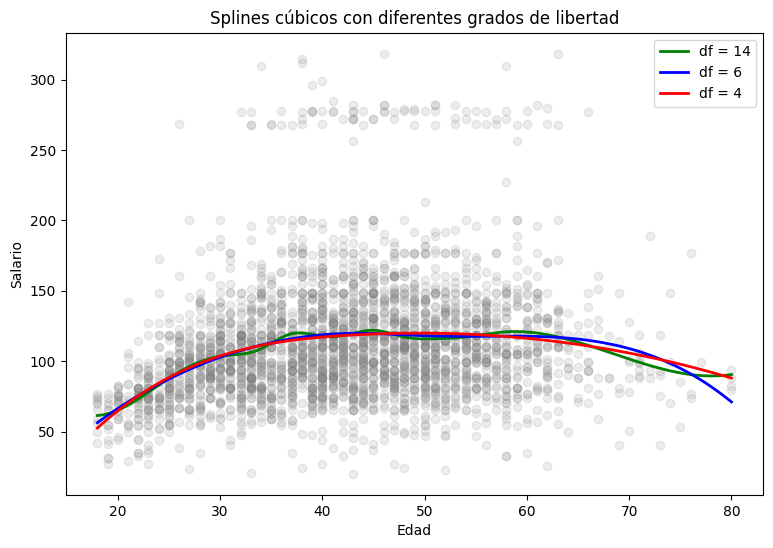

In [77]:
plt.figure(figsize=(9, 6))

plt.scatter(
    age,
    wage,
    alpha=0.15,
    color = "gray"
)

plt.plot(
    age_grid,
    pred_bs_df23["mean"],
    linewidth=2,
    color = "green",
    label="df = 14"
)

plt.plot(
    age_grid,
    pred_bs_df22["mean"],
    linewidth=2,
    color = "blue",
    label="df = 6"
)

plt.plot(
    age_grid,
    pred_bs_df21["mean"],
    linewidth=2,
    color = "red",
    label="df = 4"
)

plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title("Splines cúbicos con diferentes grados de libertad")
plt.legend()
plt.show()

Después responde:
- ¿cuál es el modelo menos flexible?

    **R:** El modelo hecho con 4 grados de flexibilidad
- ¿cuál es el más flexible?

    **R:** El modelo hecho con 14
- ¿en qué regiones son más visibles las diferencias?

    **R:** En los extremos.

**4.27.3 Ejercicio 3** Ajusta:

1) un spline cúbico con $df=8$;

In [63]:
age_grid3 = np.linspace(
    age.min(),
    age.max(),
    500
)

age_grid_df3 = pd.DataFrame({
    "age": age_grid3
})

In [64]:
#spline cúbico con df=8

bs_df_spec31 = MS([
    bs(
        "age",
        df=8
    )
]).fit(Wage)

X_bs_df31 = bs_df_spec31.transform(Wage)

model_bs_df31 = sm.OLS(
    wage,
    X_bs_df31
).fit()

X_grid_bs_df31 = bs_df_spec31.transform(age_grid_df3)

pred_bs_df31 = model_bs_df31.get_prediction(
    X_grid_bs_df31
).summary_frame()


2) un spline cúbico natural con $df=8$.

In [65]:
#spline cúbico natural con df=8

ns_age_spec3 = MS([
    ns(
        "age",
        df=8
    )
]).fit(Wage)

X_ns3 = ns_age_spec3.transform(Wage)

model_ns3 = sm.OLS(
    wage,
    X_ns3
).fit()

age_grid_df3 = pd.DataFrame({
    "age": age_grid3
})

X_grid_ns3 = ns_age_spec3.transform(
    age_grid_df3
)

pred_ns3 = model_ns3.get_prediction(
    X_grid_ns3
).summary_frame()

Grafica ambos modelos.

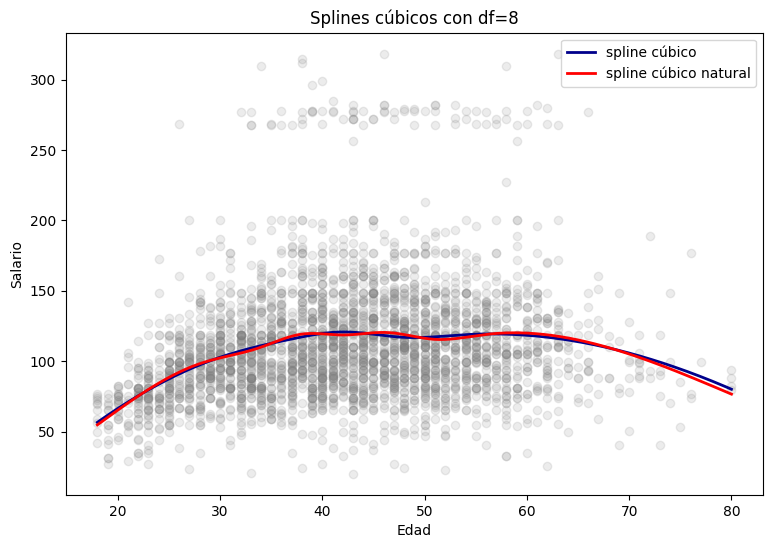

In [81]:
plt.figure(figsize=(9, 6))

plt.scatter(
    age,
    wage,
    alpha=0.15,
    color = "gray"
)

plt.plot(
    age_grid,
    pred_bs_df31["mean"],
    linewidth=2,
    color = "darkblue",
    label = "spline cúbico"
)

plt.plot(
    age_grid,
    pred_ns3["mean"],
    linewidth=2,
    color="red",
    label = "spline cúbico natural"
)

plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title("Splines cúbicos con df=8")
plt.legend()

plt.show()

Después observa especialmente:

- las edades más pequeñas;
- las edades más grandes.

¿Qué diferencia encuentras?

**R:** El spline cúbico natural tiene valores de salarios menores que el spline cúbico normal, en ambos casos (edades pequeñas y edades grandes).


**4.27.4 Ejercicio 4.** Explica con tus propias palabras la diferencia entre:

1) regresión polinómica;
2) funciones escalonadas;
3) spline cúbico;
4) spline cúbico natural.

**R:** La regresión polinómica busca una función polinomial tal que aproxime a todo el dominio de los datos; la función escalonada divide el rango de la variable predictora X en intervalos y ajuste una constante para cada una; el spline cúbico también divide el rango de la variable predictora X, no obstante, ajusta un polinomio cúbico a cada intervalo de datos; el spline cúbico natural es similar al anterior, pero que restringe a los extremos a ser lineales.


**4.27.5 Ejercicio 5.** Supón que queremos estudiar la relación entre age y wage, pero no sabemos cuántos grados de libertad utilizar.

Describe un procedimiento apropiado para seleccionar la complejidad del spline.

No es necesario implementarlo todavía.

**R:** Mediante validación cruzada. 